In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [15]:
class FourIndexLayer(nn.Module):
    def __init__(self, N):
        super().__init__()
        # Complex weights and biases
        self.W = nn.Parameter(torch.randn(N, N, N, N, dtype=torch.complex64) * 0.1)
        self.b = nn.Parameter(torch.zeros(N, N, dtype=torch.complex64))

    def forward(self, x):
        # x: [batch, N, N] complex
        ys = []
        for xx in x:  # xx: [N, N] complex
            # y_{ab} = sum_{cd} W_{abcd} * xx_{cd} + b_{ab}
            y = torch.einsum('abcd,cd->ab', self.W, xx) + self.b
            ys.append(y)
        return torch.stack(ys)

In [16]:
class Net(nn.Module):
    def __init__(self, N, depth=2):
        super().__init__()
        self.N = N
        self.layers = nn.ModuleList([FourIndexLayer(N) for _ in range(depth)])
        self.readout = nn.Linear(N*N, 1, dtype=torch.complex64)

    def forward(self, xin):
        # xin: [batch, N] complex, expand to [batch, N, N]
        x = xin.unsqueeze(2).repeat(1, 1, self.N)
        for layer in self.layers:
            x = torch.tanh(layer(x))  # torch.tanh works for complex tensors
        xflat = x.view(x.shape[0], -1)
        return self.readout(xflat)

In [17]:
# ---- Train to fit sin(3x) with complex input/output ----
N = 8
depth = 2

# Data: x in [0, 2pi], target y = sin(x), let's also make our inputs complex for flexibility
xvals = np.linspace(0, 2*np.pi, 200)
yvals = np.sin(3*xvals)
# Use complex exponential basis for input
X = np.stack([np.exp(1j*xvals*(i+1)/N) for i in range(N)], axis=1)  # [num_samples, N] complex

xtensor = torch.tensor(X, dtype=torch.complex64)
ytensor = torch.tensor(yvals, dtype=torch.complex64).unsqueeze(1)

In [18]:
# Model, loss, optimizer
model = Net(N, depth)
loss_fn = nn.MSELoss()
opt = optim.Adam(model.parameters(), lr=1e-3)
model

Net(
  (layers): ModuleList(
    (0-1): 2 x FourIndexLayer()
  )
  (readout): Linear(in_features=64, out_features=1, bias=True)
)

In [19]:
# Training loop
for epoch in range(501):
    pred = model(xtensor)
    loss = loss_fn(pred.real, ytensor.real) + loss_fn(pred.imag, ytensor.imag)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss {loss.item()}")

Epoch 0: Loss 1.353785753250122
Epoch 100: Loss 0.04785376042127609
Epoch 200: Loss 0.0018314620247110724
Epoch 300: Loss 0.0005258112796582282
Epoch 400: Loss 0.00031000457238405943
Epoch 500: Loss 0.00020381607464514673


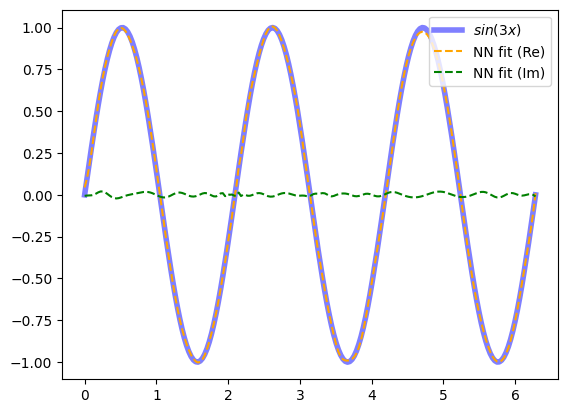

In [26]:
with torch.no_grad():
    yfit = model(xtensor).squeeze().numpy()
plt.plot(xvals, yvals, label=r'$sin(3x)$', linewidth=4, color='blue', alpha=0.5)
plt.plot(xvals, yfit.real, label='NN fit (Re)', linestyle='--', color='orange')
plt.plot(xvals, yfit.imag, label='NN fit (Im)', linestyle='--', color='green')
plt.legend()
plt.show()